<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/practicals/hh_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# @title Make nicer plots -- Execute this cell
def mystyle():
  """
  Create custom plotting style.

  Returns
  -------
  my_style : dict
      Dictionary with matplotlib parameters.

  """
  # color pallette
  style = {
      # Use LaTeX to write all text
      "text.usetex": False,
      "font.family": "DejaVu Sans",
      "font.weight": "bold",
      # Use 16pt font in plots, to match 16pt font in document
      "axes.labelsize": 16,
      "axes.titlesize": 20,
      "font.size": 16,
      # Make the legend/label fonts a little smaller
      "legend.fontsize": 14,
      "xtick.labelsize": 14,
      "ytick.labelsize": 14,
      "axes.linewidth": 2.5,
      "lines.markersize": 10.0,
      "lines.linewidth": 2.5,
      "xtick.major.width": 2.2,
      "ytick.major.width": 2.2,
      "axes.labelweight": "bold",
      "axes.spines.right": False,
      "axes.spines.top": False
  }

  return style


plt.style.use("seaborn-colorblind")
plt.rcParams.update(mystyle())

## Hodgkin-Huxley model for squid giant axon

The differential equation that governs the kinetics of the axonal membrane is:

\begin{equation}
C_m \frac{dV}{dt} = -\bar{\text{g}}_L(V-E_L) - \bar{\text{g}}_{\text{Na}}m^3h(V-E_{\text{Na}}) - \bar{\text{g}}_{\text{K}}n^4(V-E_{\text{K}}) + I_e
\end{equation}

The gating variables (i.e., $m$, $h$, and $n$) are governed by the first order kinetics:

\begin{equation}
\frac{dx}{dt}=\alpha_x(1-x) - \beta_xx
\end{equation}

which has the solution:

\begin{equation}
x(t) = x_\infty(V) - \left( n_\infty(V)-n_0) \right) \text{exp} \left( -\frac{t}{\tau_x(V)}\right)
\end{equation}

where

\begin{align}
n_\infty(V) &= \frac{\alpha_x}{\alpha_x+\beta_x} \\
\tau_x(V) &= \frac{1}{\alpha_x+\beta_x}
\end{align}

- Potassium variable (i.e, $n$)
\begin{align}
\\
\alpha_n(V) &= 0.01\frac{V+55}{1-\text{exp}(-(V+55)/10)} \\
\\
\beta_n(V) &= 0.125 \text{exp}(-(V+65)/80)
\end{align}

- Sodium activation variable (i.e, $m$)
\begin{align}
\\
\alpha_m(V) &= 0.1\frac{V+40}{1-\text{exp}(-(V+40)/10)} \\
\\
\beta_m(V) &= 4 \text{exp}(-(V+65)/18)
\end{align}

- Sodium inactivation variable (i.e, $h$)
\begin{align}
\\
\alpha_h(V) &= 4 \text{exp}(-(V+65)/20) \\
\\
\beta_h(V) &= \frac{1}{\text{exp}(-(V+35)/10)+1}
\end{align}



In [3]:
# Plot the gating variables

vm = np.linspace(-100, 50, 10000)

# Potassium variable
alpha_n = 0.01*(vm+55)/(1-np.exp(-(vm+55)/10))
beta_n = 0.125*np.exp(-(vm+65)/80)

# Sodium variables
alpha_m = 0.1*(vm+40)/(1-np.exp(-(vm+40)/10))
beta_m = 4*np.exp(-(vm+65)/18)

alpha_h = 0.07*np.exp(-(vm+65)/20)
beta_h = 1/(np.exp(-(vm+35)/10)+1)

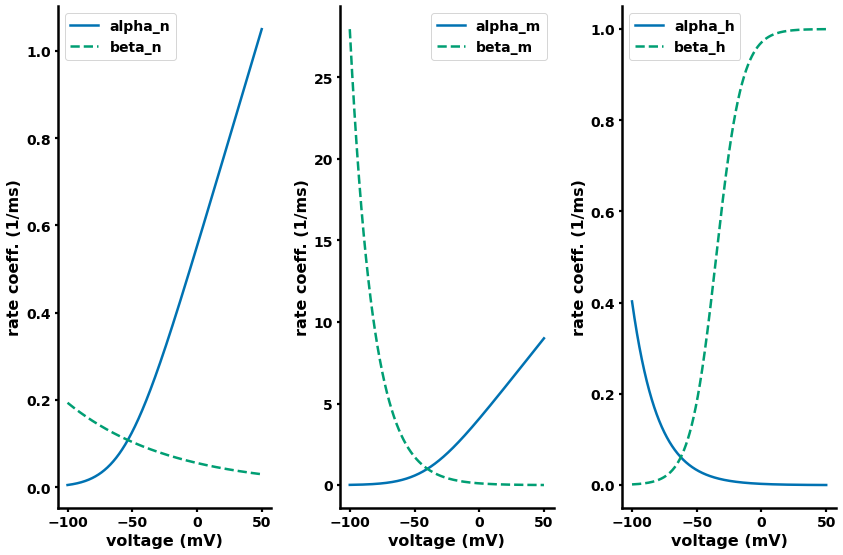

In [4]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 3, 1)
plt.plot(vm, alpha_n, label='alpha_n')
plt.plot(vm, beta_n, linestyle='dashed', label='beta_n')
plt.xlabel('voltage (mV)')
plt.ylabel('rate coeff. (1/ms)')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(vm, alpha_m, label='alpha_m')
plt.plot(vm, beta_m, linestyle='dashed', label='beta_m')
plt.xlabel('voltage (mV)')
plt.ylabel('rate coeff. (1/ms)')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(vm, alpha_h, label='alpha_h')
plt.plot(vm, beta_h, linestyle='dashed', label='beta_h')
plt.xlabel('voltage (mV)')
plt.ylabel('rate coeff. (1/ms)')
plt.legend()

plt.tight_layout()
plt.show()

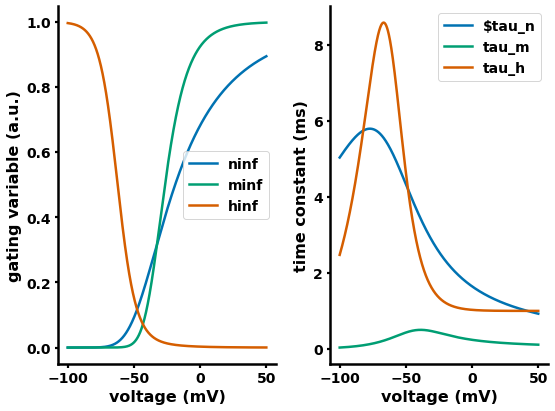

In [5]:
# Calculate the gating variable and their time constants
ninf = alpha_n / (alpha_n + beta_n)
tau_n = 1 / (alpha_n + beta_n)

minf = alpha_m / (alpha_m + beta_m)
tau_m = 1 / (alpha_m + beta_m)

hinf = alpha_h / (alpha_h + beta_h)
tau_h = 1 / (alpha_h + beta_h)


plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(vm, ninf**4, label='ninf')
plt.plot(vm, minf**3, label='minf')
plt.plot(vm, hinf, label='hinf')
plt.xlabel('voltage (mV)')
plt.ylabel('gating variable (a.u.)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(vm, tau_n, label='$tau_n')
plt.plot(vm, tau_m, label='tau_m')
plt.plot(vm, tau_h, label='tau_h')
plt.xlabel('voltage (mV)')
plt.ylabel('time constant (ms)')
plt.legend()

plt.tight_layout()
plt.show()

## HH model numerical method

Here we use a more accurate and robust method to calculate the next values. This method is know as the exponential Euler (also known as `cnexp`).

\begin{align}
x[n+1] &= x[n]\cdot \text{exp}\left( -\frac{dt}{\tau_x} \right) + x_\infty \cdot \left( 1-\text{exp}\left( -\frac{dt}{\tau_x} \right) \right) \\
x[n+1] &= x_\infty + (x[n] - x_\infty)\cdot \text{exp}\left( -\frac{dt}{\tau_x} \right)
\end{align}

where $x_\infty$ denotes the steady-state.



For the membrane voltage:

\begin{equation}
C_m \frac{dV}{dt} = -\bar{\text{g}}_L(V-E_L) - \bar{\text{g}}_{\text{Na}}m^3h(V-E_{\text{Na}}) - \bar{\text{g}}_{\text{K}}n^4(V-E_{\text{K}}) + I_e
\end{equation}

The steady-state, $V_\infty$ is given when $\frac{dV}{dt}=0$.

Thus,

\begin{align}
-\bar{\text{g}}_L(V_\infty-E_L) - \bar{\text{g}}_{\text{Na}}m^3h(V_\infty-E_{\text{Na}}) - \bar{\text{g}}_{\text{K}}n^4(V_\infty-E_{\text{K}}) + I_e = 0 &\iff \\ \\
-V_\infty (\bar{\text{g}}_L + \bar{\text{g}}_{\text{Na}}m^3h + \bar{\text{g}}_{\text{K}}n^4) = -\bar{\text{g}}_LE_L - \bar{\text{g}}_{\text{Na}}m^3hE_{\text{Na}} - \bar{\text{g}}_{\text{K}}n^4E_{\text{K}} - I_e  &\iff \\ \\
V_\infty = \frac{\bar{\text{g}}_LE_L + \bar{\text{g}}_{\text{Na}}m^3hE_{\text{Na}} + \bar{\text{g}}_{\text{K}}n^4E_{\text{K}} + I_e}{\bar{\text{g}}_L + \bar{\text{g}}_{\text{Na}}m^3h + \bar{\text{g}}_{\text{K}}n^4}
\end{align}

Also, the membrane time constant is given by:

\begin{equation}
\tau_m = C_m R_m = \frac{C_m}{\text{g}_m} = \frac{C_m}{\bar{\text{g}}_L + \bar{\text{g}}_{\text{Na}}m^3h + \bar{\text{g}}_{\text{K}}n^4}
\end{equation}

where $\text{g}_m$ denotes the total membrane conductance.

In [6]:
# Creates a custom Hodgkin and Huxley function
def HHmodel(Ie, dt, tFinal, tStimStart, tStimEnd, RestingPotential):
  # Define the model parameters
  cm = 10  # capacitance per unit area (nF/mm^2)
  gl = 3  # leak maximal conductance per unit area (mS/mm^2)
  el = -54.387  # leak conductance reversal potential (mV)
  gkbar = 360  # maximal K+ conductance per unit area (mS/mm^2)
  ek = -77  # K+ conductance reversal potential (mV)
  gnabar = 1200  # maximal Na+ conductance per unit area (mS/mm^2)
  ena = 50  # Na+ conductance reversal potential (mV)

  # sets up data structures to hold relevant variable vectors
  steps = int(tFinal/dt)
  timeVec = np.linspace(0, tFinal, steps+1)
  voltageVec = np.zeros(steps+1, )
  IeVec = np.zeros(steps+1, )
  mVec = np.zeros(steps+1, )
  hVec = np.zeros(steps+1, )
  nVec = np.zeros(steps+1, )
  tauVec = np.zeros(steps+1, )

  # assigns the initial value of each variable
  voltageVec[0] = RestingPotential 
  mVec[0] = 0.0529
  hVec[0] = 0.5961
  nVec[0] = 0.3177

  # defines the stimulus
  tStimStart = int(tStimStart/dt)
  tStimEnd = int(tStimEnd/dt)
  IeVec[tStimStart:tStimEnd+1] = Ie

  # For-loop integrates equations into model
  for n in range(steps):
    # Calculate alpha values in n, m, and h
    alpha_n = 0.01*(voltageVec[n] + 55) / (1-np.exp(-(voltageVec[n]+55)/10))
    alpha_m = 0.1*(voltageVec[n] + 40) / (1-np.exp(-(voltageVec[n]+40)/10))
    alpha_h = 0.07*np.exp(-(voltageVec[n]+65)/20)

    # Calculate beta values in n, m, and h
    beta_n = 0.125*np.exp(-(voltageVec[n]+55)/80)
    beta_m = 4*np.exp(-(voltageVec[n]+65)/18)
    beta_h = 1 / (1 + np.exp(-(voltageVec[n]+35)/10))

    # Calculate tau values in n, m, and h
    tau_n = 1 / (alpha_n + beta_n)
    tau_m = 1 / (alpha_m + beta_m)
    tau_h = 1 / (alpha_h + beta_h)

    # Calculate inf values in n, m, and h
    ninf = alpha_n/(alpha_n + beta_n)
    minf = alpha_m/(alpha_m + beta_m)
    hinf = alpha_h/(alpha_h + beta_h)

    # Calculate and store values in n, m, and h vectors
    nVec[n+1] = ninf + (nVec[n]-ninf)*np.exp(-dt/tau_n)
    mVec[n+1] = minf + (mVec[n]-minf)*np.exp(-dt/tau_m)
    hVec[n+1] = hinf + (hVec[n]-hinf)*np.exp(-dt/tau_h)

    # Updates vinf and tau_m
    numerator = gl*el + gkbar*(nVec[n]**4)*ek + gnabar*(mVec[n]**3)*hVec[n]*ena + IeVec[n]
    denominator = gl + gkbar*(nVec[n]**4) + gnabar*(mVec[n]**3)*hVec[n]  # sum of conductances
    tau_m = cm / denominator
    vinf = numerator / denominator

    # Calculates and store next voltage value in vector
    voltageVec[n+1] = vinf + (voltageVec[n]-vinf)*np.exp(-dt/tau_m)

  return voltageVec, mVec, hVec, nVec, timeVec, IeVec

In [7]:
# Simulation parameters
tFinal = 1000  # ms
dt = 0.1  # ms

tStimStart = 10  # Start of stimulus (ms)
tStimEnd = 200 # End of stimulus (ms)
Ie = 200  # injected current (nA/mm^2)

voltageVec, mVec, hVec, nVec, timeVec, IeVec = HHmodel(Ie=100, dt=0.001, tFinal=50,
                                                       tStimStart=10,
                                                       tStimEnd=15,
                                                       RestingPotential=-65)

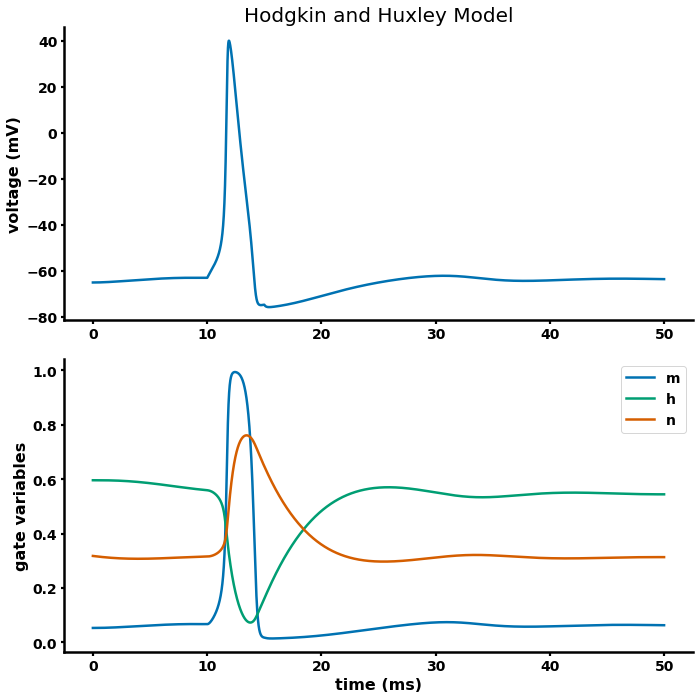

In [8]:
# Plotting
plt.figure(1, figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(timeVec, voltageVec)
plt.title('Hodgkin and Huxley Model')
plt.ylabel('voltage (mV)')
plt.subplot(2, 1, 2)
plt.plot(timeVec, mVec, label='m')
plt.plot(timeVec, hVec, label='h')
plt.plot(timeVec, nVec, label='n')
plt.ylabel('gate variables')
plt.xlabel('time (ms)')
plt.legend()

plt.tight_layout()
plt.show()